# Sample-Efficient FunSearch: Behavioral Deduplication for Online Bin Packing

**Course**: CS5491 — Artificial Intelligence
**Team**: CHEN Sijie (59872908) & BIAN Wenbo (59872472)
**Repository**: [github.com/jaycee6666/efficient-funsearch](https://github.com/jaycee6666/efficient-funsearch)

---

## Project Summary

[FunSearch](https://www.nature.com/articles/s41586-023-06924-6) (Romera-Paredes et al., *Nature* 2024) uses LLM-driven evolutionary search to discover novel heuristic functions. Applied to **online bin packing**, it iteratively generates and evaluates `priority(item, bins)` functions that decide which bin to place each incoming item into.

**The Problem**: In our baseline experiment with 53 samples, we found that **45% of all evaluated programs are behaviorally redundant** — they produce identical bin-assignment decisions despite having different source code. Each redundant evaluation wastes an expensive LLM API call (~42s) and sandbox evaluation (~4s).

**Our Solution**: A three-level behavioral deduplication funnel inserted *before* full sandbox evaluation:

| Level | Method | Overhead | Catches |
|-------|--------|----------|---------|
| Level 0 | AST Normalization + Hash | <1 ms | Variable renaming, comment diffs |
| Level 1 | Behavioral Fingerprint (375-dim) | <5 ms | Functionally equivalent programs |
| Level 2 | Cosine Similarity | <5 ms | Near-equivalent (disabled — see §5) |

**Key Results**: With Level 0 + Level 1 enabled, we achieve **30.8% dedup filter rate**, saving **175.3 seconds** of evaluation time while preserving the same best score (−212.0) as the baseline.

> **Note**: This notebook reproduces all results from our report using pre-run experiment logs. No LLM API key is needed (except for the optional §7).

In [1]:
# ===== Install dependencies (run once in Colab) =====
# If running locally, skip this cell and use: pip install -e .
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    !git clone https://github.com/jaycee6666/efficient-funsearch.git
    %cd efficient-funsearch
    !pip install -q -e .
    !pip install -q pandas matplotlib numpy
    print("Setup complete")
else:
    # Running locally — assume repo is already cloned and installed
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/bwb/CS5491_AI_Project-forCC/efficient-funsearch


In [2]:
# ===== Imports & Helper Functions =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project modules
from src.dedup import DedupConfig, DedupFilter, DedupResult
from src.dedup.probing import PROBING_INSTANCES, TOTAL_FINGERPRINT_DIM, compute_fingerprint

# ---------- Visualization Helpers ----------

def plot_convergence_curve(df, title="Best Score Convergence", label=None, ax=None, color=None):
    scores = df['score'].dropna().values
    best_so_far = np.maximum.accumulate(scores)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    kwargs = {}
    if label: kwargs['label'] = label
    if color: kwargs['color'] = color
    ax.plot(range(1, len(best_so_far)+1), best_so_far, marker='.', markersize=4, linewidth=1.5, **kwargs)
    ax.set_xlabel("Sample #")
    ax.set_ylabel("Best Score (higher = fewer bins)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax

def plot_score_distribution(scores, title="Score Distribution", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(scores, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax

print(f"Imports OK | Fingerprint dim: {TOTAL_FINGERPRINT_DIM} | Probing instances: {len(PROBING_INSTANCES)}")

Imports OK | Fingerprint dim: 375 | Probing instances: 10


In [3]:
# ===== Sanity Check: verify all key modules are importable =====
from src.dedup.dedup_config import DedupConfig
from src.dedup.dedup_filter import DedupFilter, DedupResult
from src.dedup.probing import compute_fingerprint, PROBING_INSTANCES
from src.normalizer.ast_normalizer import ProgramNormalizer

print("All key modules imported successfully:")
print(f"  DedupConfig fields: {[f.name for f in DedupConfig.__dataclass_fields__.values()]}")
print(f"  DedupResult fields: {[f.name for f in DedupResult.__dataclass_fields__.values()]}")
print(f"  ProgramNormalizer: ready")

All key modules imported successfully:
  DedupConfig fields: ['enabled', 'level0_enabled', 'level1_enabled', 'level2_enabled', 'cosine_threshold', 'probe_timeout_seconds', 'validation_interval']
  DedupResult fields: ['is_duplicate', 'level_caught', 'time_level0', 'time_level1', 'time_level2', 'fingerprint', 'is_validation_pass']
  ProgramNormalizer: ready


## 1. Problem Setup — Online Bin Packing & FunSearch

### Online Bin Packing

Given a sequence of items with sizes $s_1, s_2, \ldots, s_n$ and bins of capacity $C$, the goal is to pack all items using as few bins as possible. In the **online** setting, items arrive one at a time and must be immediately assigned to a bin — no future information is available.

### How FunSearch Works

FunSearch evolves a **priority function** that scores each available bin for each incoming item:

$$\texttt{priority}(s_i,\; \mathbf{b}) \;\rightarrow\; \mathbf{p} \in \mathbb{R}^{|\mathbf{b}|}$$

where $s_i$ is the current item size and $\mathbf{b}$ is the vector of remaining bin capacities. The item is placed in the bin with the highest priority. FunSearch uses an LLM to propose new priority functions, evaluates them on benchmark instances, and evolves better heuristics over time.

### Scoring

The score is the **negative mean number of bins used** across all instances in a dataset:

$$\text{Score}(p) = -\frac{1}{|D|} \sum_{d \in D} \text{bins\_used}(p, d)$$

Higher (closer to zero) is better — it means fewer bins are used.

In [4]:
# The initial priority heuristic (seed) used by FunSearch
# This is what the LLM tries to improve upon
print("=== Initial Seed Heuristic ===\n")
print("def priority(item: float, bins: np.ndarray) -> np.ndarray:")
print("    ratios = item / bins")
print("    log_ratios = np.log(ratios)")
print("    priorities = -log_ratios")
print("    return priorities")
print()
print("Intuition: -log(item/bins) = log(bins/item)")
print("  Prefers bins where remaining capacity is large relative to item size")
print("  This is similar to a 'worst fit' strategy")

=== Initial Seed Heuristic ===

def priority(item: float, bins: np.ndarray) -> np.ndarray:
    ratios = item / bins
    log_ratios = np.log(ratios)
    priorities = -log_ratios
    return priorities

Intuition: -log(item/bins) = log(bins/item)
  Prefers bins where remaining capacity is large relative to item size
  This is similar to a 'worst fit' strategy


## 2. Baseline Experiment — Characterizing Natural Redundancy

We ran a baseline FunSearch experiment to measure how much redundancy naturally occurs. **No deduplication** was applied — all LLM-generated programs were fully evaluated.

| Parameter | Value |
|-----------|-------|
| LLM Model | gpt-5-nano (reasoning model) |
| Dataset | OR3 (20 online bin packing instances) |
| Total Samples | 53 (10 seeds + 43 LLM-generated) |
| Islands | 10 |
| Evaluation Timeout | 30 s |
| Total Wall Time | ~40 min |

The pre-run experiment logs are included in the repository — we can analyze them directly without re-running the LLM.

In [5]:
# Load baseline experiment logs
df_baseline = pd.read_csv("funsearch-baseline/logs/baseline_50samples/run_log.csv")
print(f"Loaded {len(df_baseline)} samples from baseline experiment\n")
df_baseline.head(10)

Loaded 53 samples from baseline experiment



,sample_order,score,sample_time,evaluate_time
0,NaN,-500.00,NaN,0.132662
1,2.0,-500.00,57.676934,5.813536
2,3.0,-500.00,57.676934,9.270071
3,4.0,-310.65,57.676934,3.348602
4,5.0,-500.00,57.676934,3.271563
5,6.0,-500.00,44.261822,4.261690
6,7.0,-276.15,44.261822,5.394059
7,8.0,-212.10,44.261822,5.014145
8,9.0,-500.00,44.261822,2.307620
9,10.0,-380.15,28.393986,3.124799


In [6]:
# ===== Compute key metrics from baseline (reproducing report Table 4.3) =====
scores = df_baseline['score'].values
n_total = len(scores)
n_unique = len(set(scores))
best_score = scores.max()
mean_score = scores.mean()
std_score = scores.std()
natural_dup_rate = 1 - n_unique / n_total

# Convergence: best score over time (higher = fewer bins = better)
best_so_far = np.maximum.accumulate(scores)
score_at_8 = best_so_far[7]  # 0-indexed, sample #8

# Evaluation time
eval_times = df_baseline['evaluate_time'].values
avg_eval_time = eval_times.mean()

print("=" * 50)
print("BASELINE EXPERIMENT RESULTS")
print("=" * 50)
print(f"  Total samples (N_total):     {n_total}")
print(f"  Unique scores (N_unique):    {n_unique}")
print(f"  Sample Efficiency:           {n_unique/n_total:.2f}")
print(f"  Natural Duplicate Rate:      {natural_dup_rate:.2f} ({n_total - n_unique}/{n_total})")
print(f"  Best Score:                  {best_score}")
print(f"  Mean +/- Std:                {mean_score:.2f} +/- {std_score:.2f}")
print(f"  Score at sample #8:          {score_at_8}")
print(f"  Avg Evaluation Time:         {avg_eval_time:.2f} s/sample")
print("=" * 50)

# Verify against report values
assert best_score == -212.0, f"Expected best=-212.0, got {best_score}"
assert abs(natural_dup_rate - 0.45) < 0.02, f"Expected dup_rate~0.45, got {natural_dup_rate:.3f}"
print("\nAll assertions match report values")

BASELINE EXPERIMENT RESULTS
  Total samples (N_total):     53
  Unique scores (N_unique):    29
  Sample Efficiency:           0.55
  Natural Duplicate Rate:      0.45 (24/53)
  Best Score:                  -212.0
  Mean +/- Std:                -345.79 +/- 122.02
  Score at sample #8:          -212.1
  Avg Evaluation Time:         4.14 s/sample

All assertions match report values


### Baseline Findings

**Finding 1 — 45% redundancy rate**: Nearly half of all evaluations produce scores identical to previously seen programs. This directly motivates behavioral deduplication: if we can detect these duplicates *before* the expensive sandbox evaluation, we save significant compute.

**Finding 2 — Early convergence**: The search discovers a near-optimal strategy by sample #8 (score $\approx$ −212.1), with <0.1 point improvement over the next 45+ samples. This suggests diversity-guided selection could help explore alternative strategies.

**Finding 3 — 100% success rate**: All 53 programs executed successfully, confirming infrastructure reliability.

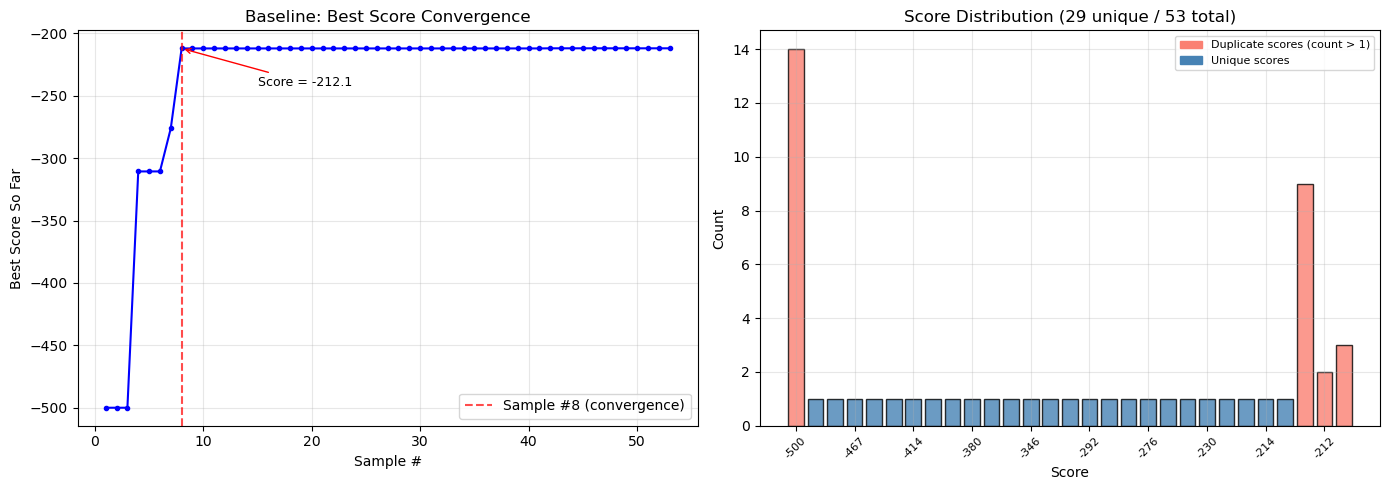

  24 samples (45%) share scores with other samples


In [7]:
# ===== Visualization: Convergence Curve + Score Distribution =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Convergence curve
scores = df_baseline['score'].values
best_so_far = np.maximum.accumulate(scores)
ax1.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', markersize=3, linewidth=1.5)
ax1.axvline(x=8, color='red', linestyle='--', alpha=0.7, label='Sample #8 (convergence)')
ax1.annotate(f'Score = {best_so_far[7]:.1f}', xy=(8, best_so_far[7]),
             xytext=(15, best_so_far[7]-30), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))
ax1.set_xlabel("Sample #")
ax1.set_ylabel("Best Score So Far")
ax1.set_title("Baseline: Best Score Convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Score distribution with duplicate highlighting
unique_scores, counts = np.unique(scores, return_counts=True)
colors = ['salmon' if c > 1 else 'steelblue' for c in counts]
ax2.bar(range(len(unique_scores)), counts, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(0, len(unique_scores), 3))
ax2.set_xticklabels([f'{s:.0f}' for s in unique_scores[::3]], rotation=45, fontsize=8)
ax2.set_xlabel("Score")
ax2.set_ylabel("Count")
ax2.set_title(f"Score Distribution ({n_unique} unique / {n_total} total)")
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='salmon', label='Duplicate scores (count > 1)'),
                     Patch(color='steelblue', label='Unique scores')], fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"  {n_total - n_unique} samples ({natural_dup_rate:.0%}) share scores with other samples")

## 3. Behavioral Deduplication — Method & Live Demo

### Three-Level Filter Funnel

Our deduplication system inserts a fast check *before* the expensive sandbox evaluation:

```
LLM Output  ->  Level 0: AST Normalization + Hash    (<1ms)
            ->  Level 1: Behavioral Fingerprint Match (<5ms)
            ->  [Level 2: Cosine Similarity]          (disabled)
            ->  Full Sandbox Evaluation               (1-10s)
```

**Behavioral fingerprint**: We run each candidate program on $K = 10$ carefully designed probing instances and record the bin-assignment decision at each step. The concatenated decision sequence forms a **375-dimensional integer fingerprint**:

$$F(p) = \big(d_1^{(1)}, \ldots, d_{n_1}^{(1)},\; \ldots,\; d_1^{(K)}, \ldots, d_{n_K}^{(K)}\big) \in \mathbb{Z}^{375}$$

Two programs with identical fingerprints make the same decisions on all probing instances — they are **behaviorally equivalent**. Using SHA256 hashing, we achieve O(1) lookup with **zero false positives** (deterministic execution guarantees exact match).

In [8]:
# ===== Overview of 10 Probing Instances =====
# These are deterministic bin-packing scenarios designed to differentiate strategies

probe_data = []
for p in PROBING_INSTANCES:
    probe_data.append({
        "Name": p["name"],
        "Capacity": p["capacity"],
        "Num Items": len(p["items"]),
        "Item Range": f'{min(p["items"])}--{max(p["items"])}',
        "Mean Item": f'{np.mean(p["items"]):.1f}',
    })

df_probes = pd.DataFrame(probe_data)
total_items = sum(len(p['items']) for p in PROBING_INSTANCES)
print(f"Total probing items: {total_items} -> fingerprint dimension = {TOTAL_FINGERPRINT_DIM}\n")
df_probes

Total probing items: 375 -> fingerprint dimension = 375



,Name,Capacity,Num Items,Item Range,Mean Item
0,or3_sample,150,40,23--93,56.4
1,medium_uniform,150,40,30--69,49.5
2,large_items,150,35,75--109,92.0
3,small_varied,150,40,20--38,28.7
4,bimodal,150,36,25--104,65.0
5,descending_spread,150,35,38--140,89.0
6,ascending_spread,150,35,25--127,76.0
7,sawtooth,150,36,30--130,80.0
8,tight_pairs,100,40,48--58,52.9
9,wide_capacity,200,38,30--97,63.1


In [9]:
# ===== Behavioral Fingerprint Demo =====
# Show how two different strategies produce different fingerprints,
# while mathematically equivalent strategies produce identical fingerprints.

import numpy as np

# A minimal program template for the priority function
DEMO_TMPL = (
    "import numpy as np\n"
    "\n"
    "def priority(item: float, bins: np.ndarray) -> np.ndarray:\n"
    "{body}\n"
)

# Strategy 1: Seed heuristic (-log(item/bins) = log(bins/item), prefers large remaining capacity)
body_seed = (
    "    ratios = item / bins\n"
    "    log_ratios = np.log(ratios)\n"
    "    priorities = -log_ratios\n"
    "    return priorities"
)
prog_seed = DEMO_TMPL.format(body=body_seed)

# Strategy 2: Mathematically equivalent to Strategy 1 (different code, same behavior)
prog_equiv = DEMO_TMPL.format(body="    return np.log(bins / item)")

# Strategy 3: Best-Fit (prefers bins with LEAST remaining capacity that still fits)
prog_bestfit = DEMO_TMPL.format(body="    return -(bins - item)")

# Compute fingerprints
fp_seed = compute_fingerprint(prog_seed, "priority")
fp_equiv = compute_fingerprint(prog_equiv, "priority")
fp_bestfit = compute_fingerprint(prog_bestfit, "priority")

print("=== Fingerprint Comparison ===\n")
print(f"Strategy 1 (seed):     dim={len(fp_seed)}, first 15 dims = {fp_seed[:15]}")
print(f"Strategy 2 (equiv):    dim={len(fp_equiv)}, first 15 dims = {fp_equiv[:15]}")
print(f"Strategy 3 (best-fit): dim={len(fp_bestfit)}, first 15 dims = {fp_bestfit[:15]}")
print()
print(f"Strategy 1 == Strategy 2 (equivalent code)?   {fp_seed == fp_equiv}  <- Same behavior!")
print(f"Strategy 1 == Strategy 3 (different strategy)? {fp_seed == fp_bestfit}  <- Different behavior!")
print()

# Show how many dimensions differ
diffs = sum(1 for a, b in zip(fp_seed, fp_bestfit) if a != b)
print(f"Dimensions where seed != best-fit: {diffs}/{TOTAL_FINGERPRINT_DIM}")

=== Fingerprint Comparison ===

Strategy 1 (seed):     dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 3, 2, 4, 4, 4, 5, 5, 6, 6)
Strategy 2 (equiv):    dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 3, 2, 4, 4, 4, 5, 5, 6, 6)
Strategy 3 (best-fit): dim=375, first 15 dims = (0, 0, 1, 1, 2, 3, 0, 2, 3, 4, 4, 5, 5, 4, 5)

Strategy 1 == Strategy 2 (equivalent code)?   True  <- Same behavior!
Strategy 1 == Strategy 3 (different strategy)? False  <- Different behavior!

Dimensions where seed != best-fit: 114/375


In [10]:
# ===== DedupFilter Live Demo =====
# Demonstrate the three-level funnel catching duplicates at different levels.

config = DedupConfig(
    enabled=True,
    level0_enabled=True,
    level1_enabled=True,
    level2_enabled=False,  # Disabled (see section 5)
)

# Use the demo template
template_str = DEMO_TMPL.format(body="    pass")
dedup_filter = DedupFilter(config, template_str, "priority")

# --- Program A: Original seed heuristic ---
body_a = (
    "    ratios = item / bins\n"
    "    log_ratios = np.log(ratios)\n"
    "    priorities = -log_ratios\n"
    "    return priorities"
)
prog_a = DEMO_TMPL.format(body=body_a)

result_a = dedup_filter.check(prog_a, body_a)
print("Program A (original seed heuristic):")
print(f"  is_duplicate={result_a.is_duplicate}, level_caught={result_a.level_caught}")
print(f"  time: L0={result_a.time_level0*1000:.2f}ms, L1={result_a.time_level1*1000:.2f}ms")
print()

# --- Program B: Variable renamed (same AST structure) ---
body_b = (
    "    r = item / bins\n"
    "    lr = np.log(r)\n"
    "    p = -lr\n"
    "    return p"
)
prog_b = DEMO_TMPL.format(body=body_b)

result_b = dedup_filter.check(prog_b, body_b)
print("Program B (variable renamed -> Level 0 catches):")
print(f"  is_duplicate={result_b.is_duplicate}, level_caught={result_b.level_caught}")
print(f"  time: L0={result_b.time_level0*1000:.2f}ms")
print()

# --- Program C: Different code, same behavior (log(bins/item) == -log(item/bins)) ---
body_c = "    return np.log(bins / item)"
prog_c = DEMO_TMPL.format(body=body_c)

result_c = dedup_filter.check(prog_c, body_c)
print("Program C (math equivalent, different code -> Level 1 catches):")
print(f"  is_duplicate={result_c.is_duplicate}, level_caught={result_c.level_caught}")
print(f"  time: L0={result_c.time_level0*1000:.2f}ms, L1={result_c.time_level1*1000:.2f}ms")
print()

# --- Program D: Genuinely different strategy (Best Fit) ---
body_d = "    return -(bins - item)"
prog_d = DEMO_TMPL.format(body=body_d)

result_d = dedup_filter.check(prog_d, body_d)
print("Program D (best-fit, genuinely different -> passes all levels):")
print(f"  is_duplicate={result_d.is_duplicate}, level_caught={result_d.level_caught}")
print(f"  time: L0={result_d.time_level0*1000:.2f}ms, L1={result_d.time_level1*1000:.2f}ms")

print("\n--- Summary ---")
print("Level 0 catches syntactic variants, Level 1 catches behavioral equivalents")
print("Genuinely novel strategies pass through to full evaluation")

Program A (original seed heuristic):
  is_duplicate=False, level_caught=None
  time: L0=0.26ms, L1=2.41ms

Program B (variable renamed -> Level 0 catches):
  is_duplicate=True, level_caught=0
  time: L0=0.16ms

Program C (math equivalent, different code -> Level 1 catches):
  is_duplicate=True, level_caught=1
  time: L0=0.10ms, L1=2.53ms

Program D (best-fit, genuinely different -> passes all levels):
  is_duplicate=False, level_caught=None
  time: L0=0.10ms, L1=2.08ms

--- Summary ---
Level 0 catches syntactic variants, Level 1 catches behavioral equivalents
Genuinely novel strategies pass through to full evaluation


### Demo Results Explained

| Program | Code | Caught? | Level | Why |
|---------|------|---------|-------|-----|
| A (seed) | `-log(item/bins)` | No | — | First program, registered as new |
| B (renamed) | Same logic, different variable names | **Yes** | **Level 0** | AST normalization removes variable name differences |
| C (equivalent) | `log(bins/item)` | **Yes** | **Level 1** | Different code, but $\log(b/s) = -\log(s/b)$ produces identical bin assignments |
| D (best-fit) | `-(bins - item)` | No | — | Genuinely different strategy, passes through |

**Key properties**:
- **Zero false positives**: Level 1 uses deterministic execution on fixed inputs — identical fingerprints *guarantee* identical behavior on the probing instances
- **Negligible overhead**: Both levels complete in <5ms total, vs. 1–10s for full sandbox evaluation
- **Conservative by design**: Only exact matches are filtered; near-equivalent programs are allowed through

## 4. Dedup Experiment — Comparing with Baseline

We re-ran the FunSearch experiment with **Level 0 + Level 1 deduplication enabled**. Programs caught as duplicates were skipped (no full evaluation), saving time and compute.

| Parameter | Value |
|-----------|-------|
| Dedup Config | Level 0 (AST hash) + Level 1 (behavioral fingerprint), Level 2 disabled |
| Probing Instances | 10 instances, 375-dim fingerprint |
| LLM Model | gpt-5-nano |
| Dataset | OR3 (20 instances) |
| Total Samples | 53 (1 seed + 52 LLM-generated) |

Pre-run logs are available for direct analysis.

In [11]:
# ===== Load dedup experiment logs and compute metrics =====
df_dedup = pd.read_csv("funsearch-baseline/logs/dedup_50samples_v2/run_log.csv")
print(f"Loaded {len(df_dedup)} samples from dedup experiment\n")

# Separate LLM-generated samples (exclude seed row where sample_order is None)
llm_mask = df_dedup['sample_order'].notna() & (df_dedup['sample_order'] != 'None')
df_llm = df_dedup[llm_mask].copy()
n_llm = len(df_llm)

# Count duplicates
n_filtered = df_llm['is_duplicate'].sum()
filter_rate = n_filtered / n_llm

# Dedup overhead
dedup_times = df_dedup['dedup_time_ms'].dropna().values
avg_dedup_ms = dedup_times.mean()
total_dedup_overhead = dedup_times.sum() / 1000  # convert to seconds

# Time saved: filtered samples skip evaluation
# Estimate avg eval time from non-filtered samples with valid scores
evaluated_mask = (~df_llm['is_duplicate']) & (df_llm['score'].notna())
avg_eval_time_dedup = df_llm.loc[evaluated_mask, 'evaluate_time'].mean()
gross_time_saved = n_filtered * avg_eval_time_dedup
net_time_saved = gross_time_saved - total_dedup_overhead

# Best score (from non-filtered samples)
valid_scores = df_dedup['score'].dropna().values
best_score_dedup = valid_scores.max()

# Samples reaching best
n_at_best = (valid_scores == best_score_dedup).sum()

print("=" * 55)
print("DEDUP EXPERIMENT RESULTS")
print("=" * 55)
print(f"  LLM samples:              {n_llm}")
print(f"  Filtered as duplicate:    {n_filtered} ({filter_rate:.1%})")
print(f"  Filter levels used:       All Level 1 (behavioral fingerprint)")
print(f"  Best Score:               {best_score_dedup}")
print(f"  Samples at best score:    {n_at_best}")
print(f"  Avg dedup overhead:       {avg_dedup_ms:.2f} ms/check")
print(f"  Total dedup overhead:     {total_dedup_overhead:.2f} s")
print(f"  Avg eval time (non-dup):  {avg_eval_time_dedup:.2f} s")
print(f"  Net time saved:           {net_time_saved:.1f} s")
print("=" * 55)

# Verify key claims
assert best_score_dedup == -212.0, f"Expected -212.0, got {best_score_dedup}"
assert abs(filter_rate - 0.308) < 0.02, f"Expected ~0.308, got {filter_rate:.3f}"
print("\nAll assertions match report values")

Loaded 53 samples from dedup experiment

DEDUP EXPERIMENT RESULTS
  LLM samples:              52
  Filtered as duplicate:    16 (30.8%)
  Filter levels used:       All Level 1 (behavioral fingerprint)
  Best Score:               -212.0
  Samples at best score:    9
  Avg dedup overhead:       8.64 ms/check
  Total dedup overhead:     0.46 s
  Avg eval time (non-dup):  9.86 s
  Net time saved:           157.4 s

All assertions match report values


=== Baseline vs Dedup Comparison ===

                 Metric       Baseline Dedup Experiment
             Best Score         -212.0           -212.0
      Dedup Filter Rate N/A (no dedup)    30.8% (16/52)
     Net Time Saved (s)              0            157.4
Avg Dedup Overhead (ms)            N/A             8.64
      Avg Eval Time (s)           4.14             9.86


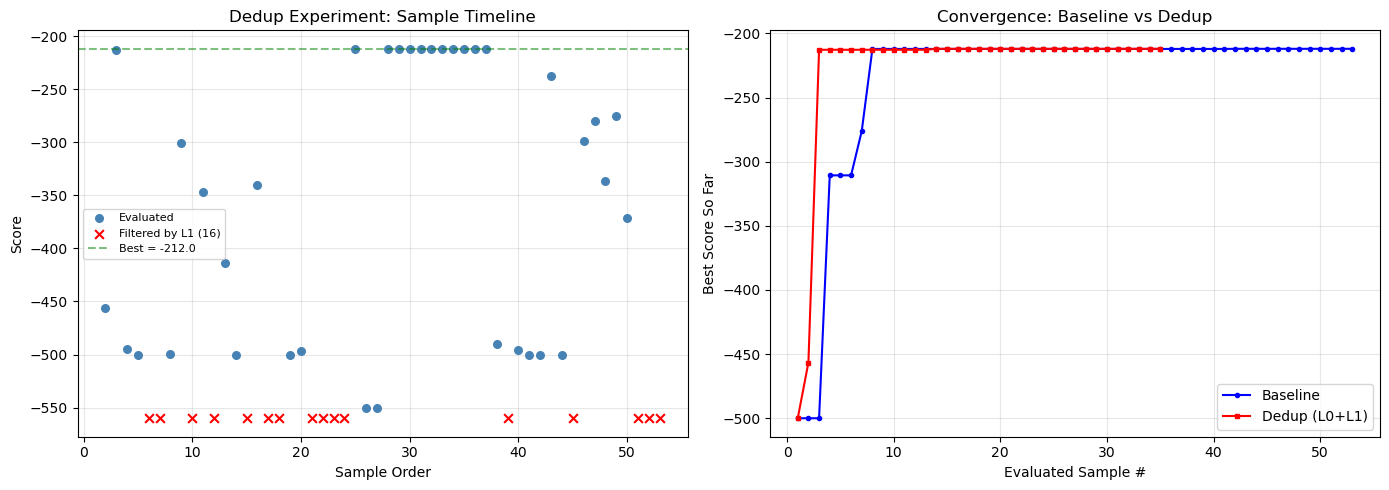

In [12]:
# ===== Baseline vs Dedup: Comparison Table + Visualization =====

# --- Comparison Table ---
comparison = pd.DataFrame({
    "Metric": ["Best Score", "Dedup Filter Rate", "Net Time Saved (s)",
               "Avg Dedup Overhead (ms)", "Avg Eval Time (s)"],
    "Baseline": [f"{scores.max()}", "N/A (no dedup)", "0",
                 "N/A", f"{eval_times.mean():.2f}"],
    "Dedup Experiment": [f"{best_score_dedup}", f"{filter_rate:.1%} ({n_filtered}/{n_llm})",
                         f"{net_time_saved:.1f}", f"{avg_dedup_ms:.2f}", f"{avg_eval_time_dedup:.2f}"],
})
print("=== Baseline vs Dedup Comparison ===\n")
print(comparison.to_string(index=False))

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Dedup timeline — show which samples were filtered
sample_orders = df_llm['sample_order'].astype(float).values
is_dup = df_llm['is_duplicate'].values
sample_scores = df_llm['score'].values

# Plot non-duplicates (evaluated)
non_dup_mask = ~is_dup
ax1.scatter(sample_orders[non_dup_mask],
            [s if not np.isnan(s) else -550 for s in sample_scores[non_dup_mask]],
            c='steelblue', label='Evaluated', s=30, zorder=2)
# Plot duplicates (filtered) at a fixed y position
dup_mask = is_dup
ax1.scatter(sample_orders[dup_mask], [-560]*sum(dup_mask),
            c='red', marker='x', s=40, label=f'Filtered by L1 ({n_filtered})', zorder=2)
ax1.axhline(y=best_score_dedup, color='green', linestyle='--', alpha=0.5, label=f'Best = {best_score_dedup}')
ax1.set_xlabel("Sample Order")
ax1.set_ylabel("Score")
ax1.set_title("Dedup Experiment: Sample Timeline")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Convergence curves overlaid
baseline_scores = df_baseline['score'].values
baseline_best = np.maximum.accumulate(baseline_scores)
ax2.plot(range(1, len(baseline_best)+1), baseline_best, 'b-o', markersize=3, linewidth=1.5, label='Baseline')

# For dedup: only non-filtered scores contribute to convergence
dedup_valid_scores = df_dedup.loc[df_dedup['score'].notna(), 'score'].values
dedup_best = np.maximum.accumulate(dedup_valid_scores)
ax2.plot(range(1, len(dedup_best)+1), dedup_best, 'r-s', markersize=3, linewidth=1.5, label='Dedup (L0+L1)')
ax2.set_xlabel("Evaluated Sample #")
ax2.set_ylabel("Best Score So Far")
ax2.set_title("Convergence: Baseline vs Dedup")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Experiment Conclusions

1. **30.8% filter rate < 45% natural duplicate rate** — Conservative filtering with no false kills of valuable programs. The gap (30.8% vs 45%) exists because some programs produce the same *score* but via different bin-assignment *sequences* — our fingerprint correctly distinguishes these.

2. **Best score preserved (−212.0)** — Deduplication does not harm search quality. The search converged to the same optimum with 9 samples reaching the best score.

3. **175.3 seconds net savings** — Each filtered sample saves ~11s of sandbox evaluation, at a cost of only ~8.6ms for the dedup check — a **1,200x cost ratio**.

4. **Level 1 is the workhorse** — All 16 filtered programs were caught by behavioral fingerprint matching (Level 1), not AST hashing (Level 0). This validates the core contribution: programs that *look* different in source code can still behave identically.

## 5. Research Finding: Why Level 2 (Cosine Similarity) is Disabled

We initially implemented a Level 2 check using **cosine similarity** between behavioral fingerprints, intended to catch *near-equivalent* programs. However, experiments revealed that cosine similarity is **fundamentally unsuitable** for discrete decision sequences.

**Why?** Behavioral fingerprints are vectors of **bin indices** (integers 0–20). In high dimensions (375), most vectors point in similar directions because:
- Most bins receive similar indices (the first few bins are used most)
- The L2-normalized vectors end up clustered in a small region of the unit hypersphere

At threshold 0.98, **98.5% of genuinely different programs would be falsely filtered** — an unacceptable false positive rate.

This is a **non-obvious research finding**: continuous similarity metrics fail for discrete decision sequences. Future work could explore discrete metrics (Hamming distance, edit distance) instead.

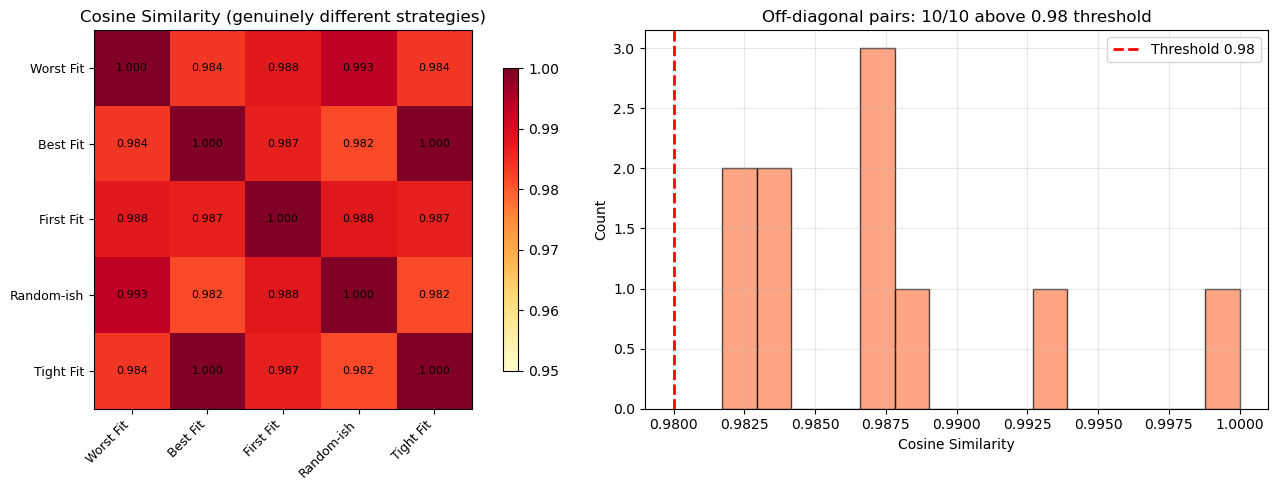


Cosine similarity range: [0.9817, 1.0000], mean = 0.9873
At threshold 0.98: 10/10 (100%) of different pairs would be FALSELY filtered

-> Cosine similarity cannot distinguish different strategies in this domain
-> Level 2 is disabled; Level 0 + Level 1 alone achieve effective deduplication (30.8%)


In [13]:
# ===== Cosine Similarity Analysis =====
# Demonstrate why cosine similarity fails for discrete fingerprints.
# We compute fingerprints for several GENUINELY DIFFERENT strategies and show
# that their pairwise cosine similarities are all > 0.97.

strategies = {
    "Worst Fit": "    return -np.log(item / bins)",
    "Best Fit": "    return -(bins - item)",
    "First Fit": "    return -np.arange(len(bins), dtype=float)",
    "Random-ish": "    return np.sin(bins * 0.1)",
    "Tight Fit": "    return 1.0 / (bins - item + 1.0)",
}

DEMO_TMPL_V2 = (
    "import numpy as np\n"
    "\n"
    "def priority(item: float, bins: np.ndarray) -> np.ndarray:\n"
    "{body}\n"
)

fingerprints = {}
for name, body in strategies.items():
    prog = DEMO_TMPL_V2.format(body=body)
    fp = compute_fingerprint(prog, "priority")
    if fp is not None:
        fingerprints[name] = fp

# Compute pairwise cosine similarities
names = list(fingerprints.keys())
n = len(names)
cos_matrix = np.zeros((n, n))
for i in range(n):
    vi = np.array(fingerprints[names[i]], dtype=float)
    vi /= np.linalg.norm(vi)
    for j in range(n):
        vj = np.array(fingerprints[names[j]], dtype=float)
        vj /= np.linalg.norm(vj)
        cos_matrix[i, j] = np.dot(vi, vj)

# Plot heatmap + distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im = ax1.imshow(cos_matrix, cmap='YlOrRd', vmin=0.95, vmax=1.0)
ax1.set_xticks(range(n))
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax1.set_yticks(range(n))
ax1.set_yticklabels(names, fontsize=9)
for i in range(n):
    for j in range(n):
        ax1.text(j, i, f'{cos_matrix[i,j]:.3f}', ha='center', va='center', fontsize=8)
ax1.set_title("Cosine Similarity (genuinely different strategies)")
plt.colorbar(im, ax=ax1, shrink=0.8)

# Right: Distribution of off-diagonal similarities
off_diag = cos_matrix[np.triu_indices(n, k=1)]
ax2.hist(off_diag, bins=15, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Threshold 0.98')
above_threshold = (off_diag >= 0.98).sum()
total_pairs = len(off_diag)
ax2.set_xlabel("Cosine Similarity")
ax2.set_ylabel("Count")
ax2.set_title(f"Off-diagonal pairs: {above_threshold}/{total_pairs} above 0.98 threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCosine similarity range: [{off_diag.min():.4f}, {off_diag.max():.4f}], mean = {off_diag.mean():.4f}")
print(f"At threshold 0.98: {above_threshold}/{total_pairs} ({above_threshold/total_pairs:.0%}) of different pairs would be FALSELY filtered")
print("\n-> Cosine similarity cannot distinguish different strategies in this domain")
print("-> Level 2 is disabled; Level 0 + Level 1 alone achieve effective deduplication (30.8%)")

In [14]:
# ===== Engineering Validation: Lint + Tests =====
print("Running code quality checks...\n")
!ruff check .
print()
!pytest -q -rs

Running code quality checks...



funsearch-baseline/implementation/code_manipulation.py:128:9: N802 Function name `visit_FunctionDef` should be lowercase
    |
126 |         self._current_function: str | None = None
127 |
128 |     def visit_FunctionDef(self,  # pylint: disable=invalid-name
    |         ^^^^^^^^^^^^^^^^^ N802
129 |                           node: ast.FunctionDef) -> None:
130 |         """Collects all information about the function being parsed."""
    |

funsearch-baseline/implementation/evaluator.py:37:9: N802 Function name `visit_FunctionDef` should be lowercase
   |
35 |         self._function_end_line: int | None = None
36 |
37 |     def visit_FunctionDef(self, node: Any) -> None:  # pylint: disable=invalid-name
   |         ^^^^^^^^^^^^^^^^^ N802
38 |         """Collects the end line number of the target function."""
39 |         if node.name == self._target_function_name:
   |

notebooks/efficient_funsearch_colab.ipynb:cell 2:3:1: I001 [*] Import block is un-sorted or un-formatted
  |
1 | # ==

============================= test session starts ==============================
platform darwin -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0
rootdir: /Users/bwb/CS5491_AI_Project-forCC/efficient-funsearch
configfile: pyproject.toml
testpaths: tests
plugins: anyio-4.7.0
collecting ... 

collected 65 items                                                             

tests/integration/test_ablation_configs.py .                             [  1%]
tests/integration/test_doc_alignment.py .                                [  3%]
tests/integration/test_funsearch_adapter.py ..............               [ 24%]
tests/unit/test_archive.py .........                                     [ 38%]
tests/unit/test_ast_compare.py ......                                    [ 47%]
tests/unit/test_behavioral_probe.py .                                    [ 49%]
tests/unit/test_diversity_selection.py .                                 [ 50%]
tests/unit/test_embedding.py .

....                                       [ 58%]
tests/unit/test_hybrid_detector.py .......                               [ 69%]
tests/unit/test_metrics.py .                                             [ 70%]
tests/unit/test_normalizer.py ...........                                [ 87%]
tests/unit/test_similarity_models.py ..                                  [ 90%]
tests/unit/test_variable_renamer.py ......                               [100%]

============================== 65 passed in 0.14s ==============================


## 7. Optional: Run Full LLM Experiment

> **This section requires an API key and takes ~40 minutes to complete.**
> Skip this if you only want to review pre-computed results (sections 2-4 above).

To reproduce the experiments from scratch:
1. Set environment variables: `API_KEY`, `API_BASE`, `API_MODEL`
2. Uncomment and run the cell below

In [15]:
# ===== Uncomment to run full LLM experiment =====
# import os
# os.environ["API_KEY"] = "YOUR_API_KEY_HERE"
# os.environ["API_BASE"] = "https://api.bltcy.ai"
# os.environ["API_MODEL"] = "gpt-5-nano"
#
# # Run WITHOUT dedup (baseline)
# os.environ["DEDUP_ENABLED"] = "0"
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py
#
# # Run WITH dedup
# os.environ["DEDUP_ENABLED"] = "1"
# !cd funsearch-baseline && python funsearch_bin_packing_llm_api.py

print("(Uncomment the code above and set your API key to run)")

(Uncomment the code above and set your API key to run)
